In [1]:
import sys
sys.path.append('../')

import numpy as np
import scipy.sparse as ssp
import matplotlib.pyplot as plt
import qutip as qt
import scqubits as scq
from matplotlib.colors import LogNorm
from tqdm import tqdm
from qutip.qip.operations import rz, cz_gate
import cmath
from sympy import symbols
import utils_2Q_gate_zp as ut
ut.set_fig_font() ### Set various sizes in plotting
import scipy as sp
from joblib import Parallel, delayed
import pandas as pd
import itertools
from qutip.qip.operations import rz, cz_gate, cnot, rx, hadamard_transform

In [22]:
cz300= pd.read_csv('data/data_cz_sesolve_truc1=300.txt')
cz300_se= pd.read_csv('data/data_cz_sesolve_truc1=300_select.txt')
cz300_se_v2= pd.read_csv('data/data_cz_sesolve_truc1=300_select_v2.txt')
cz80 = pd.read_csv('data/data_cz_sesolve_truc1=80.txt')
cz80_se = pd.read_csv('data/data_cz_sesolve_truc1=80_select.txt')
# cz_old = pd.read_csv('data/data_fig/data_cz_n2_20.txt')
# pa = np.column_stack((pa, f_300_700))
# df = pd.DataFrame(cz300_se_v2, columns=['tg', 'drive_amp', 'detune', 'f_300_200', 'f_300_700'])
# df.to_csv('data/data_cz_sesolve_truc1=300_select_v2.txt', sep=',', index=False, header=True)

In [32]:
f_300_500 = np.array([
[20.077003, -0.4304431807286377] ,
[26.043284, -0.5756690927197206] ,
[31.931254, -0.5955240000503583] ,
[38.082317, -0.6033025248666004] ,
[44.061218, -0.852969475213978] ,
[50.083415, -1.0895247456810508] ,
[56.025239, -1.280796913212383] ,
[62.092027, -1.4491160667062126] ,
[68.042765, -1.600531521186606] ,
[73.993407, -1.7362673822313963] ,
[79.985745, -1.8174340396591042] ,
[85.968536, -1.8430888337431413] ,
[92.003021, -1.927252768982951] ,
[98.095432, -2.1618566684728995] ,
[104.099756, -2.5072995650284122] ,
[110.068882, -2.9184857251131167] ,
[116.094656, -3.045493281328949] ,
[121.906996, -2.9306739618653395] ,
[128.094457, -2.9685547350383916] ,
[134.008265, -3.1613014404576765] ,
[140.00363, -3.2942741176393326] ,
[146.000607, -3.3122272416787113] ,
[152.007024, -3.4290417517442284] ,
[158.00117, -3.6832402574809815] ,
[164.004109, -3.8890569981184475] ,
[170.00114, -4.018603482857845] ,
[176.009278, -4.249009094595264] ,
[182.001711, -4.348281820362137] ,
[188.000168, -4.196739488919509] ,
[194.00424, -4.080694740092048] ,
[200.006185, -3.918985706219968] ,
])

f_400_500 = np.array([
[20.077003, -0.2192835747735014] ,
[26.043284, -0.5232918357188014] ,
[31.931254, -0.6475310873990133] ,
[38.082317, -0.32283959828888475] ,
[44.061218, -0.461487715646283] ,
[50.083415, -0.6854275913722658] ,
[56.025239, -0.9225055470424302] ,
[62.092027, -1.1896931392532295] ,
[68.042765, -1.3959023471570335] ,
[73.993407, -1.625497513866311] ,
[79.985745, -1.7649918590115106] ,
[85.968536, -1.7084649029544214] ,
[92.003021, -1.5318854185993427] ,
[98.095432, -1.5864682704793875] ,
[104.099756, -1.8000780986995877] ,
[110.068882, -2.035374565839137] ,
[116.094656, -2.2286220050836016] ,
[121.906996, -2.339288915108187] ,
[128.094457, -2.394640913716861] ,
[134.008265, -2.5461319737130093] ,
[140.00363, -2.6818820115373483] ,
[146.000607, -2.757280874769845] ,
[152.007024, -2.8706888833447475] ,
[158.00117, -3.0057321143591538] ,
[164.004109, -3.144006731712669] ,
[170.00114, -3.232148278364547] ,
[176.009278, -3.3457315887986483] ,
[182.001711, -3.4609985654652586] ,
[188.000168, -3.5436836458354124] ,
[194.00424, -3.53955208416644] ,
[200.006185, -3.5708335653212946] ,
])
f_500_500 = np.array([
[20.077003, -0.21928356801907498] ,
[26.043284, -0.5232918935630284] ,
[31.931254, -0.6475314956399607] ,
[38.082317, -0.3228395868787535] ,
[44.061218, -0.4614877116726273] ,
[50.083415, -0.6854276546812796] ,
[56.025239, -0.9225057225245253] ,
[62.092027, -1.189692919189142] ,
[68.042765, -1.3959041708764879] ,
[73.993407, -1.6254948554338737] ,
[79.985745, -1.7649934829672467] ,
[85.968536, -1.708466287076133] ,
[92.003021, -1.531888602531441] ,
[98.095432, -1.5864741769412773] ,
[104.099756, -1.8000758489833324] ,
[110.068882, -2.035364200327335] ,
[116.094656, -2.2286007678261623] ,
[121.906996, -2.3392882584458343] ,
[128.094457, -2.3946441052644776] ,
[134.008265, -2.546151536888399] ,
[140.00363, -2.681919977517285] ,
[146.000607, -2.7572613195767066] ,
[152.007024, -2.870711671934364] ,
[158.00117, -3.00580103737163] ,
[164.004109, -3.1438383985939393] ,
[170.00114, -3.232314676023154] ,
[176.009278, -3.3457910850934107] ,
[182.001711, -3.4606769120571466] ,
[188.000168, -3.5438275800804075] ,
[194.00424, -3.5397352328928906] ,
[200.006185, -3.5705974059419963] ,
])



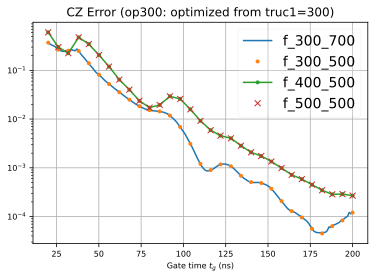

In [34]:
fig, ax = plt.subplots(figsize=(6,4))
plt.plot(cz300['tg'], 10**(cz300['f_300_700']), '-',  label=r'f_300_700')
# plt.plot(cz300_se_v2['tg'], 10**(cz300_se_v2['f_300_700']), '.',  label=r'f_300_700')
plt.plot(cz300_se_v2['tg'], 10**(f_300_500[:,1]), '.',  label=r'f_300_500')
plt.plot(cz300_se_v2['tg'], 10**(f_400_500[:,1]), '.-',  label=r'f_400_500')
plt.plot(cz300_se_v2['tg'], 10**(f_500_500[:,1]), 'x',  label=r'f_500_500')


plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title('CZ Error (op300: optimized from truc1=300)', fontsize=12)
plt.grid()
legend = plt.legend(loc='best', fontsize=14)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

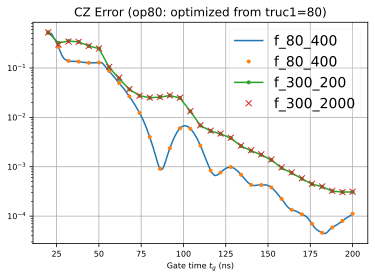

In [4]:
fig, ax = plt.subplots(figsize=(6,4))
plt.plot(cz80['tg'], 10**cz80['f_80_400'], '-',  label=r'f_80_400')
plt.plot(cz80_se['tg'], 10**cz80_se['f_80_400'], '.',  label=r'f_80_400')
plt.plot(cz80_se['tg'], 10**cz80_se['f_300_200'], '.-',  label=r'f_300_200')
plt.plot(cz80_se['tg'], 10**cz80_se['f_300_2000'], 'x',  label=r'f_300_2000')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title('CZ Error (op80: optimized from truc1=80)', fontsize=12)
plt.grid()
legend = plt.legend(loc='best', fontsize=14)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

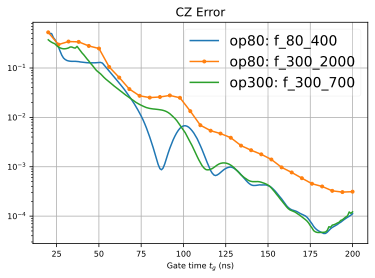

In [5]:
fig, ax = plt.subplots(figsize=(6,4))
plt.plot(cz80['tg'], 10**cz80['f_80_400'], '-',  label=r'op80: f_80_400')
plt.plot(cz80_se['tg'], 10**cz80_se['f_300_2000'], '.-',  label=r'op80: f_300_2000')
plt.plot(cz300['tg'], 10**(cz300['f_300_700']), '-',  label=r'op300: f_300_700')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title('CZ Error', fontsize=12)
plt.grid()
legend = plt.legend(loc='best', fontsize=14)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [7]:
f_400_500 = np.array([
[20.074749, -0.21732231391785756] ,
[26.083127, -0.5068310849616271] ,
[31.988187, -0.6492735031657489] ,
[38.08762, -0.3164819120919714] ,
[44.058392, -0.4626675916169598] ,
[50.086935, -0.6889039524047555] ,
[56.087064, -0.9407050230478031] ,
[62.091833, -1.1771180304243227] ,
[68.078194, -1.397194095894895] ,
[74.046222, -1.616922734670189] ,
[80.062878, -1.7703613340921445] ,
[86.032572, -1.7168064528375282] ,
[91.997815, -1.515231729905221] ,
[98.047029, -1.593456033269596] ,
[104.064603, -1.7690442829894246] ,
[110.088003, -2.0365921587336637] ,
[115.947545, -2.2211438184611247] ,
[121.933936, -2.327019823657786] ,
[128.082335, -2.421308704800871] ,
[134.094898, -2.5384669176404695] ,
[140.010415, -2.6917729398826933] ,
[145.916957, -2.2065939352340074] ,
[152.086256, -2.351482431315154] ,
[158.066044, -2.470331165288442] ,
[164.020744, -3.128726201095099] ,
[170.017014, -2.682156761357737] ,
[176.059985, -2.784202646389618] ,
[181.973222, -3.460257874383197] ,
[188.079439, -2.945957457420703] ,
[193.944023, -3.04713362678511] ,
[199.946739, -3.114435911723047] ,
])

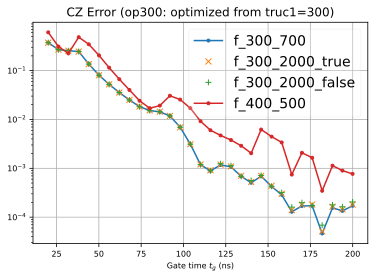

In [14]:
fig, ax = plt.subplots(figsize=(6,4))
# plt.plot(cz300['tg'], 10**(cz300['f_300_700']), '-',  label=r'f_300_700')
plt.plot(cz300_se['tg'], 10**(cz300_se['f_300_700']), '.-',  label=r'f_300_700')
plt.plot(cz300_se['tg'], 10**(cz300_se['f_300_2000']), 'x',  label=r'f_300_2000_true')
plt.plot(cz300_se['tg'], 10**cz300_se['f_300_2000_false'], '+',  label=r'f_300_2000_false')
plt.plot(cz300_se['tg'], 10**f_400_500[:,1], '.-',  label=r'f_400_500')
# plt.plot(cz80['tg'], 10**f200, '.',  label=r'f_300_200')
# plt.plot(cz80['tg'], 10**f700, 'x',  label=r'f_300_700')
# plt.plot(cz80['tg'], 10**cz80['f_80_200'], '-',  label=r'f_80_200')
# plt.plot(cz_se['tg'], 10**cz_se['f_300_2000'], '.-',  label=r'f_300_2000')
# plt.plot(cz_se['tg'], 10**cz300['f_300_2000'], '.-',  label=r'f_300_2000_new')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title('CZ Error (op300: optimized from truc1=300)', fontsize=12)
plt.grid()
legend = plt.legend(loc='best', fontsize=14)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [ ]:
=

In [7]:
f_300_200 = np.array([
-0.49615128, -0.45561566, -0.39999307, -0.34195359 ,
-0.29235226, -0.34330087, -0.39113125, -0.44173915 ,
-0.49338094, -0.54524923, -0.59644954 ,
])
f_300_700 = np.array([
-0.52622892, -0.48324866, -0.42427294, -0.36336949 ,
-0.26761333, -0.3213138, -0.36998291, -0.41734865 ,
-0.46366479, -0.50888876, -0.55648623 ,
])
pa =np.array([
[27.002075, 0.044032, 0.024957] ,
[28.004505, 0.044006, 0.024969] ,
[29.001588, 0.044002, 0.025] ,
[30.001597, 0.044002, 0.02498] ,
[31.008723, 0.05, 0.004962] ,
[32.008245, 0.049922, 0.007309] ,
[33.009192, 0.048925, 0.008961] ,
[34.009908, 0.047893, 0.010034] ,
[35.006813, 0.046826, 0.011137] ,
[36.008908, 0.045742, 0.012202] ,
[37.009057, 0.044789, 0.013395] ,
])


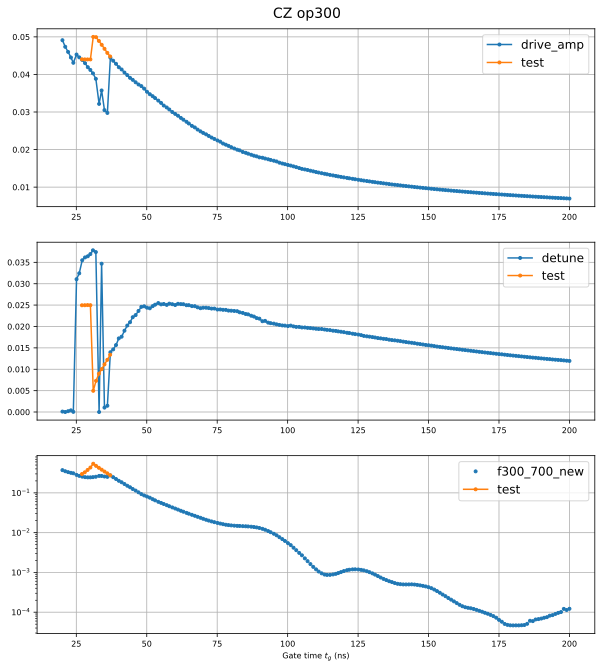

In [43]:
fig, ax = plt.subplots(figsize=(10,10), nrows=3)
fig.suptitle('CZ op300', fontsize=14)
fig.subplots_adjust(top=0.95)
ax[0].plot(cz300['tg'], cz300['drive_amp'], '.-',  label=r'drive_amp')
ax[1].plot(cz300['tg'], cz300['detune'], '.-',  label=r'detune')
# ax[2].plot(cz300['tg'], 10**cz300['f_300_200'], '.-',  label=r'f300_200_new')
ax[2].plot(cz300['tg'], 10**cz300['f_300_700'], '.',  label=r'f300_700_new')
ax[0].plot(pa[:,0], pa[:,1], '.-',  label=r'test')
ax[1].plot(pa[:,0], pa[:,2], '.-',  label=r'test')
ax[2].plot(pa[:,0], 10**f_300_700, '.-',  label=r'test')


# ax[0].plot(cz['tg'], cz['drive_amp'], '.-',  label=r'drive_amp')
# ax[1].plot(cz['tg'], cz['detune'], '.-',  label=r'detune')
# ax[2].plot(cz['tg'], 10**(cz['f_200']), '.-',  label=r'fidelity_new')
plt.xlabel('Gate time $t_g$ (ns)')
# ax[0].set_ylim(0.04, 0.05)
# ax[1].set_ylim(0.01, 0.02)
# ax[0].set_ylim(0.0065, 0.009)
# ax[1].set_ylim(0.01, 0.02)
ax[2].set_yscale('log')
for i in range(3):
    ax[i].legend(loc='best', fontsize=12)
    ax[i].grid()
    # ax[i].set_xlim(25, 40)
    # ax[i].set_xlim(150, 200)

In [6]:
print(1/(100* 2*np.pi *1e-6))
print(1/(100 *1e-6))

1591.5494309189535
10000.0


In [7]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

In [14]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

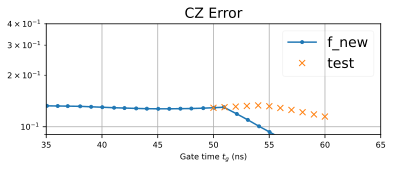

In [ ]:
fig, ax = plt.subplots(figsize=(6,2))
plt.plot(cz2['tg'], 10**(cz2['f_200']), '.-',  label=r'f_new')
# plt.plot(cz_old['tg'], 10**(cz_old['fidelity_qt']), '.-',  label=r'f_old')
plt.plot(df['tg'], 10**(df['f_200']), 'x',  label=r'test')
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title('CZ Error', fontsize=14)
plt.grid()
ax.set_xlim(35, 65)
ax.set_ylim(9e-2, 4e-1)
# ax.set_xlim(150, 201)
legend = plt.legend(loc='best', fontsize=14)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

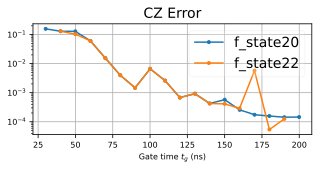

In [ ]:
f_state22 = np.array([
-0.88582615, -0.98697914, -1.21706309, -1.81364923 ,
-2.39911686, -2.83587101, -2.17886544, -2.58324798 ,
-3.16799898, -3.03628328, -3.37181672, -3.38614619 ,
-3.53888651, -2.24174523, -4.26769406, -3.90221664 ,
])
tg22 = np.arange(40, 200, 10)
fig, ax = plt.subplots(figsize=(5,2))
plt.plot(cz['tg'], 10**(cz['f_200']), '.-',  label=r'f_state20')
plt.plot(tg22, 10**f_state22, '.-',  label=r'f_state22')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title('CZ Error', fontsize=14)
plt.grid()
legend = plt.legend(loc='best', fontsize=14)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

### n1 vs n2

In [47]:
f_n2_20 = pd.read_csv('data/data_fig/data_cz_n2_20.txt')
# tg_n2_22 = [40.0, 48.0, 56.0, 64.0,
#             72.0, 80.0, 88.0, 96.0,
#             104.0, 112.0, 120.0, 128.0,
#             136.0 ]
# f_n2_22 =  np.array([
# -0.8161715873390495, -1.198271187931911, -1.7594098104987108, -2.023481051551432 ,
# -2.3286657288782977, -2.7725947360658125, -2.8755953682970254, -3.1700680471833538 ,
# -3.285110444999763, -3.3547861537801977, -3.6555773638603917, -4.002191076971732 ,
# -3.756590540402148 ,
# ])
tg_n1_20 = np.linspace(40, 200, num=21)
f_n1_20 =  np.array([
-0.6788422009241489, -0.8273402721895291, -1.159557848336972, -1.5101943758724257 ,
-1.7118085090127932, -2.676954154341082, -3.0620885220467233, -3.4685087216748425 ,
-3.5305489836403576, -3.694736067684019, -3.5295116266794095, -3.4281627762740223 ,
-3.809473799225181, -4.5005631859144755, -4.5909233374599445, -4.380422006608994 ,
-4.269258022720013, -4.131695168225334, -4.030945740857079, -3.9857467419876857 ,
-4.0631473815725805
])

tg_n1_20_k11 =  np.array([
40.0, 46.0, 52.0, 58.0 ,
64.0, 70.0, 76.0, 82.0 ,
88.0, 94.0, 100.0 ,
])
f_n1_20_k11 =  np.array([
-0.6787571403170322, -0.7840224466359769, -0.9294651962067562, -1.2342476528565633 ,
-1.5101827973402506, -1.6856272710140634, -2.2678394617485584, -2.480496337914263 ,
-3.062047398026912, -3.639748542869371, -3.221233504849732 ,
])
f_n1n2_20_k11 =  np.array([
-0.6162097733444539, -0.7432477052506214, -0.8803205086353373, -1.0182339020022375 ,
-1.145297240280844, -1.346329531305885, -1.5857552068199687, -1.8706817221542356 ,
-2.170647735119183, -2.335343517287301, -2.4973221023385466 ,
])
f_n1_00 =  np.array([
-0.5886852204952149, -0.8075146729709541, -1.0559025555318895, -1.3597443049015168 ,
-1.7119339585326072, -2.6761220066673523, -3.062169162700722, -3.46838411436316 ,
-3.53024642127191, -3.6953943630513115, -3.5308950396284633, -3.428288851913472 ,
-3.809384776659836, -4.50053327654272, -4.590881985227773, -4.380360258810188 ,
-4.268406760557727, -4.131933451137084, -4.030632593363932, -3.9854147507377204 ,
-3.935447361086711 ,
])
f_n1_22 =  np.array([
-0.6787707865867112, -0.8273818922188472, -1.1595645265077459, -1.510193275231373 ,
-1.7119685420146196, -2.676852996511711, -3.0621894814669575, -3.4679151741193874 ,
-3.5306734410936795, -3.6949819355585256, -3.5308061244866837, -3.428188619388921 ,
-3.8085449164033847, -4.500466320427937, -4.591121683370864, -4.380168880773497 ,
-4.268686111804918, -4.131951251930413, -4.0311298237958475, -3.985422179901248 ,
-4.062727894619917 ,
])
tg_n1n2_20 = [40.0, 48.0, 56.0 ,]
f_n1n2_20 =  np.array([-0.616172996364993, -0.7877798870601149, -0.9729419369959393 ,])
# f_n1n2_00 =  np.array([-0.6161361703614281, -0.7877805289182075, -0.9728984513629764 ,])




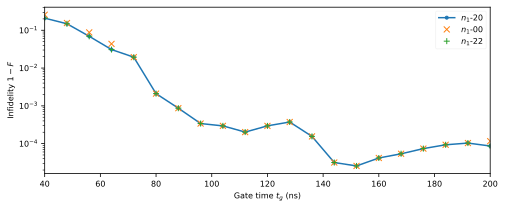

In [50]:
fig, ax = plt.subplots(figsize=(8,3))
# plt.plot(f_n2_20['tg'], 10**f_n2_20['fidelity_qt'], '.-',  label=r'$n_2$-20')
# plt.plot(tg_n2_22, 10**f_n2_22, 'x',  label=r'$n_2$-22')
plt.plot(tg_n1_20, 10**f_n1_20, '.-', label=r'$n_1$-20')
# plt.plot(tg_n1_20_k11, 10**f_n1_20_k11, 'x', label=r'$n_1$-20-k11')
# plt.plot(tg_n1_20_k11, 10**f_n1n2_20_k11, '.-', label=r'$n_1n_2$-20-k11')
plt.plot(tg_n1_20, 10**f_n1_00, 'x', label=r'$n_1$-00')
plt.plot(tg_n1_20, 10**f_n1_22, '+', label=r'$n_1$-22')
# plt.plot(tg_n1n2_20, 10**f_n1n2_20, '.-', label=r'$n_1n_2$-20')
# plt.plot(tg_n1n2_20, 10**f_n1n2_00, 'x', label=r'$n_1n_2$-20')
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.ylabel('Infidelity $1-F$')
# plt.grid()
plt.xlim(40,200)
# plt.ylim(5e-6,2e-1)
legend = plt.legend(loc='best')
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [17]:
tg_vec = np.linspace(40, 200, num=21)

# param = np.loadtxt('data/0815/aaa.txt', delimiter=',')
f_40 =  [-0.9070845082051546, -1.2598973169220298, -1.849313479425224, -2.116756844048582,
-2.403782531642886, -2.8511412131950387, -2.9697040751011623, -3.270950576996622,
-3.4164628913980426, -4.041826216786483, -3.7768887863243155, -4.059237374862007,
-3.845976129230374, -4.213672599770272, -4.989193208162769, -4.509901945861088,
-4.460128704615228, -4.3340550458755285, -4.507361305797105, -4.489470911585019, -4.461971925164813]
f_1600_9 =  [-0.9051693670250833, -1.2541215281965623, -1.821955392485761, -2.0542721955855776,
-2.2684515512212635, -2.5128483573769076, -2.526328680501479, -2.575381270016941,
-2.6046796908219085, -2.6112251811250555, -2.5080990043267097, -2.487977868148923,
-2.4526414064027775, -2.4486309078983597, -2.4436790542026876, -2.3816708400500906,
-2.3690808838006037, -2.3444688503377913, -2.32391502201516, -2.3029017936292075, -2.285922216733808]
f_1600_100 = [
-0.9068451680149641, -1.2591930365003756, -1.8459588935092535, -2.109101779348597 ,
-2.3863203863467346, -2.797759213935785, -2.892449670293085, -3.1151200300254196 ,
-3.209972793465119, -3.455983026111865, -3.3194505021583565, -3.3739926980659485 ,
-3.2994485051201456, -3.3611336889778727, -3.4006952186505104, -3.332468601422884 ,
-3.3156069563165134, -3.2845757594306466, -3.277372951342401, -3.2570965444052784 ,
-3.2392648048466253 ,
]
inf_40 = [10**(f_40[i]) for i in range(len(f_40))]
inf_1600_9 = [10**(f_1600_9[i]) for i in range(len(f_1600_9))]
inf_1600_100 = [10**(f_1600_100[i]) for i in range(len(f_1600_100))]

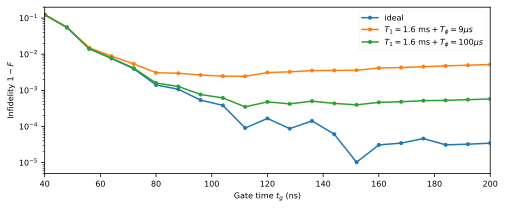

In [18]:
fig, ax = plt.subplots(figsize=(8,3))
plt.plot(tg_vec, inf_40, '.-', color=colors[0], label=r'ideal')
plt.plot(tg_vec, inf_1600_9, '.-', color=colors[1], label=r'$T_1=1.6\ {\rm ms}+T_{\phi}=9\mu s$')
plt.plot(tg_vec, inf_1600_100, '.-', color=colors[2], label=r'$T_1=1.6\ {\rm ms}+T_{\phi}=100\mu s$')
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.ylabel('Infidelity $1-F$')
# plt.grid()
plt.xlim(40,200)
plt.ylim(5e-6,2e-1)
legend = plt.legend(loc='best')
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [19]:
f_dark = [
-0.7867512886745673, -0.9551963708402209, -1.1420776767573262, -1.5493438035097946 ,
-1.844010610154276, -2.3756863372014254, -2.8650409394621548, -3.2723739468972037 ,
-3.5143757812020398, -3.792153104827175, -3.7479638808557874, -3.734591322105788 ,
-3.4899611895777536, -3.5603791939172122, -4.020406620485938, -4.30131792076429 ,
-4.299283735896858, -4.718291932412348, -4.404821234286704 ,]
inf_dark = [10**(f_dark[i]) for i in range(len(f_dark))]
f_dark_correct = [
-0.5729442295730862, -0.7340924459606013, -0.9013088096394402, -1.1460086836430365 ,
-1.355531221288533, -1.452637538253877, -1.8078364038462877, -2.3802384797234093 ,
-2.4954763756068172, -3.129480716937766, -3.5249555678663325, -3.8916312978101613 ,
-3.556304412205746, -3.6021348106232898, -3.6705502487505584, -3.6652231253260728 ,
-3.678208104250878, -3.748775481544553, -3.894908359125151 ,]
inf_dark_correct = [10**(f_dark_correct[i]) for i in range(len(f_dark_correct))]

In [20]:
# columns = ['tg', 'fidelity', 'fidelity_qt', 'detuning', 'drive_amp', 'd_eta']
# df = pd.DataFrame(para_dark2, columns=columns)
# df.to_csv('data/data_cz_n1n2_20_dark.txt', sep=',', index=False, header=True)

In [107]:
columns = ['tg', 'fidelity', 'fidelity_qt', 'detuning', 'drive_amp']
f_cz = pd.read_csv('data/data_cz_n2_20.txt').to_numpy()
param_40 = []
param_41 = []
param_42 = []
param_44 = []
param_46 = []
for i in range(20):
    param_40.append(f_cz[8*i+0].tolist())
    param_42.append(f_cz[8*i+2].tolist())
    param_44.append(f_cz[8*i+4].tolist())
    param_46.append(f_cz[8*i+6].tolist())
param_40 = np.array(param_40)
param_42 = np.array(param_42)
param_44 = np.array(param_44)
param_46 = np.array(param_46)
for i in range(80):
    param_41.append(f_cz[2*i+1].tolist())
param_41 = np.array(param_41)


In [23]:
f_3000_50 = np.array([
-1.0573659748319053, -1.4518658769357982, -2.004866724572045, -2.286257435207804 ,
-2.54816328853917, -3.0518798136742453, -3.2055619650565492, -2.9754678665541157 ,
-3.0231722994328836, -3.1006160611266367, -3.1039869086954015, -3.147509930727078 ,
-3.1563560637026864, -3.148857367631352, -3.1257969664381777, -3.081577430169305 ,
-3.0606960365349476, -3.039547044825624, -3.016524886574164, -2.9945874307840747 ,
])
f_1600_9 = np.array([
-1.0546849247768006, -1.4436402731946916, -1.9695384548865447, -2.2074842440961207 ,
-2.386585545238544, -2.6249916436640106, -2.636708565702304, -2.5325987047667042 ,
-2.512889261972158, -2.507522743152992, -2.49332538396722, -2.484534788643627 ,
-2.4589065405330075, -2.4397635063125427, -2.4110861826277903, -2.369213893931757 ,
-2.3467199807752865, -2.326899445412735, -2.305605088261082, -2.2871739614008657 ,
])
f_1600_inf = np.array([
-1.057915120335492, -1.4535466283539333, -2.012387962959724, -2.3042962278755166 ,
-2.59060948801512, -3.2369188145371504, -3.5649444807003876, -3.175748350379705 ,
-3.296813369851095, -3.510189407018998, -3.551258127902551, -3.752212416714567 ,
-3.932324532260614, -4.005740038413646, -4.033212319477393, -3.9791442947932856 ,
-3.974464476148602, -3.942189711808516, -3.906410328206737, -3.8565014251167553 ,
])
f_inf_9 = np.array([
-1.0547661430091686, -1.4439067916932993, -1.9706113448613576, -2.2095808671577553 ,
-2.390000810624503, -2.6314329453496392, -2.6438768224847644, -2.538666358018633 ,
-2.51917031945312, -2.5140400297670604, -2.500323277944648, -2.491891970542443 ,
-2.4661625546351886, -2.4471449814283814, -2.4182863109209563, -2.375801371088189 ,
-2.353253030737154, -2.3334530683532595, -2.3120961226395313, -2.293679252345233 ,
])
columns_dark = ['tg', 'fidelity', 'fidelity_qt', 'detuning', 'drive_amp', 'd_eta']

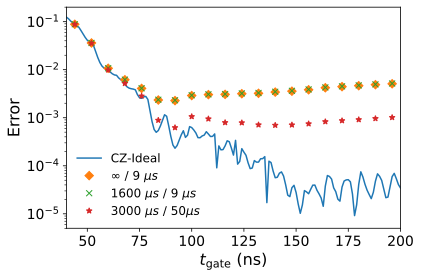

In [24]:
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16
plt.rc('font', size=MEDIUM_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE, labelsize=BIGGER_SIZE)     # fontsize of the axes
plt.rc(['xtick', 'ytick' ], labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

fig, ax = plt.subplots(figsize=(6,4))
plt.plot(f_cz[:,0], 10**f_cz[:,2], '-', color=colors[0], label=r'CZ-Ideal')
# plt.plot(param_44[:,0], 10**param_44[:,2], '.-', color=colors[0], label=r'CNOT-Ideal')
# plt.plot(param_44[:,0], 10**f_1600_inf, '.-', color=colors[3], label=r'$1600\ \mu s\ /\ \infty$')
plt.plot(param_44[:,0], 10**f_inf_9, 'D', color=colors[1], label=r'$\infty \ /\ 9\ \mu s$')
plt.plot(param_44[:,0], 10**f_1600_9, 'x', color=colors[2], label=r'$1600\ \mu s\ /\ 9\ \mu s$')
plt.plot(param_44[:,0], 10**f_3000_50, '*', color=colors[3], label=r'$3000\ \mu s\ /\ 50\mu s$')

plt.yscale('log')
plt.xlabel(r'$t_{\rm gate}$ (ns)')
plt.ylabel('Error')
# plt.grid()
plt.xlim(40,200)
plt.ylim(5e-6,2e-1)
legend = plt.legend(loc='lower left')
legend.get_frame().set_alpha(0.)  # 0.5 makes the legend 50% transparent
# plt.savefig('image/cz_error-vs-tg.png', dpi=300, bbox_inches='tight')


In [25]:
f_dark_1600_9 = np.array([
-1.181869026846921, -1.6002934513435612, -2.143804433875458, -2.4597448880419366 ,
-2.62877878625774, -2.6402254899592488, -2.6568170457474407, -2.605302818521059 ,
-2.590357810634136, -2.545152339842838, -2.5075544540162573, -2.4948646867445365 ,
-2.4544546022457547, -2.431054142877603, -2.4109866582631008, -2.3707119783301973 ,
-2.3680681972671094, -2.3257767615337746, -2.3284537506199, -2.302244148558135 ,
])

f_dark2_1600_9 = np.array([
-1.0209004694853765, -1.2127535382344241, -1.3077729018802497, -1.2869131632894737 ,
-1.2556396099181864, -1.216601101490664, -1.181773645785523, -1.1457353266188643 ,
-1.1246956785577127, -1.0921986737840128, -1.0660729932763284, -1.0460980560027433 ,
-1.0232267321376218, -1.00421275609436, -0.9872030004301335, -0.9664264334493061 ,
-0.9550561231047586, -0.9354290218468009, -0.9263209696542967, -0.9114130950430218 ,
])

f_dark_100_0_gamma23 = np.array([
-1.1786068695698706, -1.5876303166552106, -2.099297342718124, -2.397705052466336 ,
-2.5354050392985346, -2.536992069875457, -2.5647836982036685, -2.564702751889363 ,
-2.541010777714606, -2.6498897815245877, -2.6512369927141006, -2.6314367463741837 ,
-2.6254535800397987, -2.4901494124913226, -2.589577872738631, -2.5796252150734795 ,
-2.5584570093508816, -2.5617114522769695, -2.531515171597609, -2.519018613829867 ,
])

f_dark_3000_50 = np.array([
-1.1859710297018904, -1.6133670384521213, -2.203194447442735, -2.6380806629813063 ,
-2.974254765550469, -3.0922242603604815, -3.277819038720722, -3.2652574332456634 ,
-3.190974484008638, -3.2249272240065356, -3.198629970479388, -3.2162822762806007 ,
-3.1614631672199835, -3.143560129117952, -3.125815942203839, -3.0924839366016137 ,
-3.0839195438294293, -3.047962456820806, -3.0481542601141296, -3.027648727972774 ,
])
param2 = []
for i in range(20):
    param2.append(f_cz[8*i+4].tolist())
para = np.array(param2)
# para

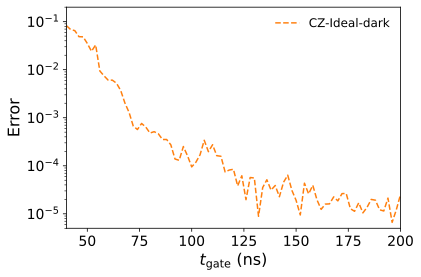

In [27]:
fig, ax = plt.subplots(figsize=(6,4))
# plt.plot(params[:,0], 10**params[:,2], '-', color=colors[0], label=r'CZ-Ideal')
# plt.plot(param_44[:,0], 10**f_1600_9, '+', color=colors[4], label=r'$1600\ \mu s\ /\ 9\ \mu s$')
# plt.plot(param_44[:,0], 10**f_3000_50, 'D', color=colors[5], label=r'$3000\ \mu s\ /\ 50\mu s$')

plt.plot(f_cz_dark[:,0], 10**f_cz_dark[:,2], '--', color=colors[1], label=r'CZ-Ideal-dark')
# plt.plot(para[:,0], 10**f_dark_1600_9, 'x', color=colors[2], label=r'ZL:$1600\ \mu s\ /\ 9\ \mu s$')
# plt.plot(para[:,0], 10**f_dark2_1600_9, 'D', color=colors[2], label=r'$1600\ \mu s\ /\ 9\ \mu s$')
# plt.plot(para[:,0], 10**f_dark_3000_50, '*', color=colors[3], label=r'$3000\ \mu s\ /\ 50\ \mu s$ - dark')
# tg = 200
# g = 0.75
# plt.axhline(y= g*tg/1000e3, color='b', linestyle='--')
# plt.axhline(y= g*tg/100e3, color='b', linestyle='--')
plt.yscale('log')
plt.xlabel(r'$t_{\rm gate}$ (ns)')
plt.ylabel('Error')
# plt.title(f'Fit: g={g}')
# plt.grid()
plt.xlim(40,200)
plt.ylim(5e-6,2e-1)
legend = plt.legend(loc='best')
legend.get_frame().set_alpha(0.)  # 0.5 makes the legend 50% transparent
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.savefig('../image/cz_error-vs-tg_dark.pdf', dpi=300, bbox_inches='tight')


In [29]:
# f_dark_0_10_oplist = np.array([
# -1.1784362457627657, -1.600930668984733, -2.0910552380818146, -2.391529650812574 ,
# -2.5123092700542933, -2.5774328607434054, -2.747860120060501, -2.7444228678118594 ,
# -2.44528550897792, -2.3963701992210416, -2.34711162068442, -2.349784889172325 ,
# -2.2885213096791386, -2.6251330496005196, -2.243725246199628, -2.28521336496759 ,
# -2.194081434222072, -2.2393311277560537, -2.1422947422203316, -2.1674151595969184 ,
# ])

# f_dark_0_100_oplist = np.array([
# -1.1861028720661115, -1.6149712588274288, -2.2038229569460697, -2.6533364495318357 ,
# -3.003171288578587, -3.1733377022555302, -3.5368118342529806, -3.598781373209999 ,
# -3.2691861455507647, -3.328943077686961, -3.2950072826112975, -3.3410988507883665 ,
# -3.259049834085927, -3.576725468025104, -3.224309124642154, -3.2701687450668464 ,
# -3.1757627064197114, -3.2246540577381966, -3.1288357487516922, -3.1607641312458132 ,


In [30]:
f_dark_1000_0_0gamma23 = np.array([
-1.1867666703025175, -1.6159325323152438, -2.2156341861776006, -2.6834044997576054 ,
-3.0910512513102777, -3.284777366151496, -3.701483352288329, -3.793148391040039 ,
-3.565080587909601, -3.794103825570761, -3.8108541862560865, -3.967145126800921 ,
-3.8414923764749735, -3.8743986293283683, -3.8426525120046593, -3.860174310923478 ,
-3.8053501132332004, -3.8187484694217537, -3.7910333138225702, -3.8119484733640427 ,
])

f_dark_1000_0_10gamma23 = np.array([
-1.1861025621768044, -1.6135375481552099, -2.2049190495875743, -2.6522898468541545 ,
-3.010286616303303, -3.1489021059353535, -3.399204623376329, -3.4432124181059978 ,
-3.330969857903929, -3.53361479500762, -3.5518082740924406, -3.611299094045365 ,
-3.562830502444493, -3.4516616388952324, -3.5490042816478886, -3.5535170880401816 ,
-3.5199719883961995, -3.5352084630592344, -3.5038694677614726, -3.5075554812842467 ,
])

f_dark_1000_0_100gamma23 = np.array([
-1.1801770891883931, -1.5925917631480195, -2.118078151469134, -2.441698170125981 ,
-2.6066546697385493, -2.6144791124181834, -2.6572332345408145, -2.6669353058903758 ,
-2.653357054385383, -2.828019135636401, -2.847276252919296, -2.8330830021922617 ,
-2.8401013874684584, -2.632001723887316, -2.813249640845993, -2.8074527932259055 ,
-2.7914662952842155, -2.808510415000504, -2.774063560584427, -2.763477728821953 ,
])

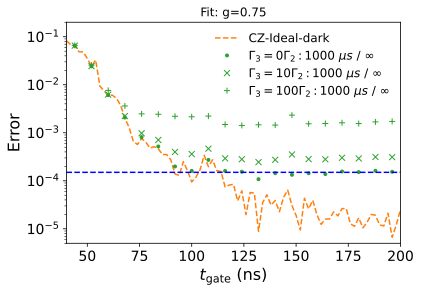

In [31]:
fig, ax = plt.subplots(figsize=(6,4))
plt.plot(f_cz_dark[:,0], 10**f_cz_dark[:,2], '--', color=colors[1], label=r'CZ-Ideal-dark')
plt.plot(para[:,0], 10**f_dark_1000_0_0gamma23, '.', color=colors[2], label=r'$\Gamma_3=0\Gamma_2:1000\ \mu s\ /\ \infty$')
plt.plot(para[:,0], 10**f_dark_1000_0_10gamma23, 'x', color=colors[2], label=r'$\Gamma_3=10\Gamma_2:1000\ \mu s\ /\ \infty$')
plt.plot(para[:,0], 10**f_dark_1000_0_100gamma23, '+', color=colors[2], label=r'$\Gamma_3=100\Gamma_2:1000\ \mu s\ /\ \infty$')

tg = 200
g = 0.75
plt.axhline(y= g*tg/1000e3, color='b', linestyle='--')
# plt.axhline(y= g*tg/100e3, color='b', linestyle='--')
plt.yscale('log')
plt.xlabel(r'$t_{\rm gate}$ (ns)')
plt.ylabel('Error')
plt.title(f'Fit: g={g}')
# plt.grid()
plt.xlim(40,200)
plt.ylim(5e-6,2e-1)
legend = plt.legend(loc='best')
legend.get_frame().set_alpha(0.)  # 0.5 makes the legend 50% transparent
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.savefig('../image/cz_error-vs-tg_dark.pdf', dpi=300, bbox_inches='tight')


In [32]:
#################################
f_dark_1000_0_oplist = np.array([
-1.1867666703025175, -1.6159325323152438, -2.2156341861776006, -2.6834044997576054 ,
-3.0910512513102777, -3.284777366151496, -3.701483352288329, -3.793148391040039 ,
-3.565080587909601, -3.794103825570761, -3.8108541862560865, -3.967145126800921 ,
-3.8414923764749735, -3.8743986293283683, -3.8426525120046593, -3.860174310923478 ,
-3.8053501132332004, -3.8187484694217537, -3.7910333138225702, -3.8119484733640427 ,
])
#################################
f_dark_100_0_oplist = np.array([
-1.1851703255298667, -1.6106890332813526, -2.1922032100779036, -2.609184724066303 ,
-2.9021013799991193, -3.0022498932626815, -3.141117703049448, -3.1342754867143148 ,
-3.031637574923834, -3.0384116164721235, -3.014644216745796, -3.01000603681934 ,
-2.970851886449323, -2.9839405002874484, -2.9276847269059427, -2.915537640435693 ,
-2.8839131882682922, -2.8718147320823757, -2.8468497367554746, -2.8357080411009776 ,
])

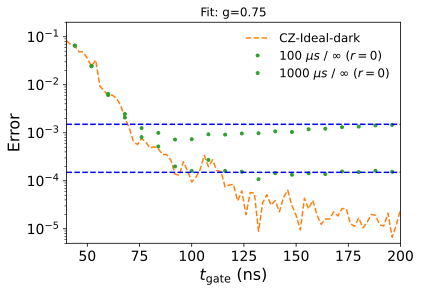

In [33]:
fig, ax = plt.subplots(figsize=(6,4))
plt.plot(f_cz_dark[:,0], 10**f_cz_dark[:,2], '--', color=colors[1], label=r'CZ-Ideal-dark')
plt.plot(para[:,0], 10**f_dark_100_0_oplist, '.', color=colors[2], label=r'$100\ \mu s\ /\ \infty\ (r=0)$')
plt.plot(para[:,0], 10**f_dark_1000_0_oplist, '.', color=colors[2], label=r'$1000\ \mu s\ /\ \infty\ (r=0)$')
tg = 200
g = 0.75
plt.axhline(y= g*tg/1000e3, color='b', linestyle='--')
plt.axhline(y= g*tg/100e3, color='b', linestyle='--')
plt.yscale('log')
plt.xlabel(r'$t_{\rm gate}$ (ns)')
plt.ylabel('Error')
plt.title(f'Fit: g={g}')
# plt.grid()
plt.xlim(40,200)
plt.ylim(5e-6,2e-1)
legend = plt.legend(loc='best')
legend.get_frame().set_alpha(0.)  # 0.5 makes the legend 50% transparent
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.savefig('../image/cz_error-vs-tg_dark.pdf', dpi=300, bbox_inches='tight')


In [34]:
f_0_10_r0 = np.array([ # ratio = 0
-1.077453019382125, -1.3023297050739404, -1.9386429390089854, -2.099539254215521 ,
-2.274225254291767, -2.307016353632379, -2.371651082262373, -2.22083056747898 ,
-2.4285954683429636, -2.405766363042772, -2.1234530559994496, -2.038930018591436 ,
-1.9920063539195916, -2.3453019953551313, -1.9951230934635003, -1.9479360531463579 ,
-1.9199803590919562, -1.9041817191969181, -1.89871104147584, -1.886463818238399 ,
])

f_0_100_r0 = np.array([
-1.08335186409443, -1.3151509578661753, -2.016939944440978, -2.2611051339128823 ,
-2.950458102076347, -3.042451306719301, -3.1840099852728536, -3.080151672698599 ,
-3.300382470400138, -3.289820581227957, -3.0782242651492444, -3.011298560180331 ,
-2.9681827138855454, -3.306730518859775, -2.9887675002549416, -2.9375735247277825 ,
-2.909669313871294, -2.8961302433059792, -2.8913014944794644, -2.8797183510838495 ,
])

f_1600_50_r0 = np.array([
-1.0826133946716379, -1.3135510667406884, -2.0065785282589386, -2.2380951936426836 ,
-2.7963157570008152, -2.8652743483752934, -2.984253428694135, -2.838898101125046 ,
-3.0351160584658086, -3.039847657208591, -2.7860677631635307, -2.710488440127052 ,
-2.6655430881848066, -2.9994158867165197, -2.674921460605465, -2.626748940431045 ,
-2.5997942065611865, -2.5835608563455814, -2.5791141860478657, -2.566851420825501 ,
])

f_1600_50_r10 = np.array([
-1.0645790073480201, -1.2761453153646654, -1.8259627688964384, -1.934526633493299 ,
-2.107595959743552, -2.1234162894063697, -2.1250158295854233, -2.094449400924085 ,
-2.102412382409353, -2.085464664185565, -2.20581608552785, -2.161033902955939 ,
-2.1590230702634745, -2.046890325643061, -2.0702682466870987, -2.080256421605017 ,
-2.100158064852972, -2.0386611629813656, -2.0871100096115867, -2.0800728919545284 ,
])

f_1600_50_r100 = np.array([
-0.9330594464786695, -1.0445471980149625, -1.22941496761878, -1.2218594389657957 ,
-1.254509238730096, -1.262880836529637, -1.247914675925693, -1.2222544082190447 ,
-1.219524375578926, -1.207083187655578, -1.3308642540235915, -1.2716034275997512 ,
-1.2844939860746518, -1.1951552306165354, -1.1751955957247897, -1.2003870684550577 ,
-1.2369303472255846, -1.162577170522272, -1.2354525491886006, -1.2339690924016935 ,
])



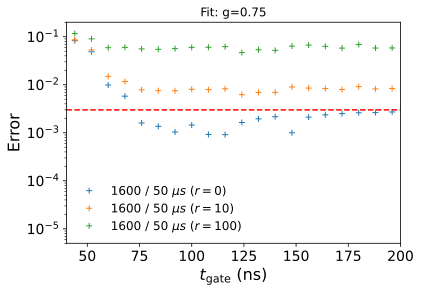

In [35]:
fig, ax = plt.subplots(figsize=(6,4))
# plt.plot(para_dark[:,0], 10**para_dark[:,2], '--', color=colors[1], label=r'CZ-Ideal-dark')
plt.plot(para[:,0], 10**f_1600_50_r0, '+', color=colors[0], label=r'$1600\ /\ 50\ \mu s\ (r=0)$')
plt.plot(para[:,0], 10**f_1600_50_r10, '+', color=colors[1], label=r'$1600\ /\ 50\ \mu s\ (r=10)$')
plt.plot(para[:,0], 10**f_1600_50_r100, '+', color=colors[2], label=r'$1600\ /\ 50\ \mu s\ (r=100)$')
tg = 200
g = 0.75
plt.axhline(y=g * tg/50e3, color='r', linestyle='--')
# plt.axhline(y=g * tg/10e3, color='r', linestyle='--')
plt.yscale('log')
plt.xlabel(r'$t_{\rm gate}$ (ns)')
plt.ylabel('Error')
plt.title(f'Fit: g={g}')
# plt.grid()
plt.xlim(40,200)
plt.ylim(5e-6,2e-1)
legend = plt.legend(loc='best')
legend.get_frame().set_alpha(0.)  # 0.5 makes the legend 50% transparent
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.savefig('../image/cz_error-vs-tg_dark.pdf', dpi=300, bbox_inches='tight')


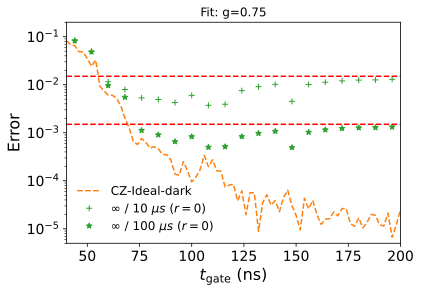

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
plt.plot(f_cz_dark[:,0], 10**f_cz_dark[:,2], '--', color=colors[1], label=r'CZ-Ideal-dark')
plt.plot(para[:,0], 10**f_0_10_r0, '+', color=colors[2], label=r'$\infty\ /\ 10\ \mu s\ (r=0)$')
plt.plot(para[:,0], 10**f_0_100_r0, '*', color=colors[2], label=r'$\infty\ /\ 100\ \mu s\ (r=0)$')
tg = 200
g = 0.75
plt.axhline(y=g * tg/100e3, color='r', linestyle='--')
plt.axhline(y=g * tg/10e3, color='r', linestyle='--')
plt.yscale('log')
plt.xlabel(r'$t_{\rm gate}$ (ns)')
plt.ylabel('Error')
plt.title(f'Fit: g={g}')
# plt.grid()
plt.xlim(40,200)
plt.ylim(5e-6,2e-1)
legend = plt.legend(loc='best')
legend.get_frame().set_alpha(0.)  # 0.5 makes the legend 50% transparent
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.savefig('../image/cz_error-vs-tg_dark.pdf', dpi=300, bbox_inches='tight')


In [85]:
f_1600_9_r0 = np.array([
-1.0766694718850158, -1.300640806913398, -1.9291267119254742, -2.0823071759521454 ,
-2.2321392199623076, -2.2632696663027176, -2.2589753112958366, -2.1743051631392065 ,
-2.380616316118754, -2.358289817185083, -2.075811129480029, -1.9915637541240978 ,
-1.9447155990112757, -2.2947842584462403, -1.9472834702227946, -1.9003311161204193 ,
-1.8723533268527544, -1.856435419981659, -1.8509637224104998, -1.8386808684825098 ,
])

f_1600_9_r0_tg44 = np.array([
-1.1682295397597806, -1.5822925641191392, -1.9728660075325322, -2.1832192516185884 ,
-2.2281293843938004, -2.2735254810370353, -2.4170823974638513, -2.4072026462626352 ,
-2.1112952567597496, -2.05382758625602, -2.0038268914075834, -2.003537858736673 ,
-1.9451908231626964, -2.2769403496213747, -1.8977898997523648, -1.9391996376068439 ,
-1.8483990849244611, -1.8905926714647203, -1.7966729265082253, -1.8196415720648196 ,
])

f_1600_100_r0_tg44 = np.array([
-1.1851322362779273, -1.613018537750157, -2.188158507075542, -2.6126100893370077 ,
-2.9015194305962373, -3.028613752030297, -3.29649013987716, -3.3491340729169154 ,
-3.0348187617938236, -3.037649807679861, -2.9960121976524494, -3.015651516712926 ,
-2.947827978153804, -3.2508189670852636, -2.9066116040327024, -2.9467481629300236 ,
-2.8576246292641656, -2.9010339128867613, -2.808480693690277, -2.834156330971088 ,
])

f_1600_100_r10_tg44 = np.array([
-1.1740720924578332, -1.5724089171764415, -2.049673953486879, -2.302741480731999 ,
-2.3809620737466384, -2.383919502461643, -2.3928576153807364, -2.41538386810818 ,
-2.3389597510265445, -2.4533969467222887, -2.4634581440290972, -2.431716582409807 ,
-2.4369398386215653, -2.3152794523886087, -2.394171412122901, -2.4148054897373314 ,
-2.3622549398483677, -2.4059821979426004, -2.3376944945552895, -2.3347946695931965 ,
])

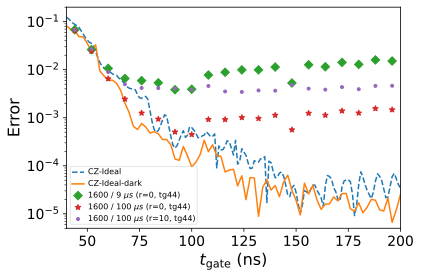

In [111]:
fig, ax = plt.subplots(figsize=(6,4))
plt.plot(f_cz[:,0], 10**f_cz[:,2], '--', color=colors[0], label=r'CZ-Ideal')
plt.plot(f_cz_dark[:,0], 10**f_cz_dark[:,2], '-', color=colors[1], label=r'CZ-Ideal-dark')
# plt.plot(para[:,0], 10**f_1600_9_r0, '*', color=colors[1], label=r'$1600\ /\ 9\ \mu s$')
plt.plot(para[:,0], 10**f_1600_9_r0_tg44, 'D', color=colors[2], label=r'$1600\ /\ 9\ \mu s$ (r=0, tg44)')
plt.plot(para[:,0], 10**f_1600_100_r0_tg44, '*', color=colors[3], label=r'$1600\ /\ 100\ \mu s$ (r=0, tg44)')
plt.plot(para[:,0], 10**f_1600_100_r10_tg44, '.', color=colors[4], label=r'$1600\ /\ 100\ \mu s$ (r=10, tg44)')
# plt.plot(para[:,0], 10**f_1600_50_r0, '.', color=colors[4], label=r'$1600\ /\ 9\ \mu s$')
tg = 200
g = 0.75
# plt.axhline(y=g * tg/9e3, color='r', linestyle='--')
# plt.axhline(y=g * tg/100e3, color='r', linestyle='--')
plt.yscale('log')
plt.xlabel(r'$t_{\rm gate}$ (ns)')
plt.ylabel('Error')
# plt.title(f'Fit: g={g}')
# plt.grid()
plt.xlim(40,200)
plt.ylim(5e-6,2e-1)
legend = plt.legend(
    loc="best",
    frameon=True,
    handlelength=1.5,
    handletextpad=0.5,
    handleheight=0.01,
    borderpad=0.2, fontsize=8,
)
legend.get_frame().set_alpha(0.5)  # 0.5 makes the legend 50% transparent
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.savefig('../image/cz_error-vs-tg_dark.pdf', dpi=300, bbox_inches='tight')


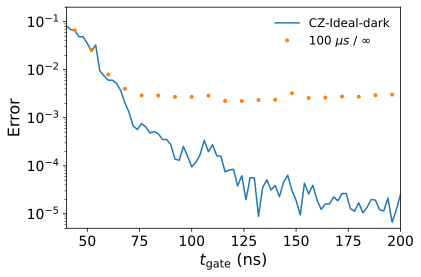

In [39]:
fig, ax = plt.subplots(figsize=(6,4))
# plt.plot(params[:,0], 10**params[:,2], '--', color=colors[0], label=r'CZ-Ideal')
# plt.plot(param_44[:,0], 10**f_1600_9, '+', color=colors[4], label=r'$1600\ \mu s\ /\ 9\ \mu s$')
# plt.plot(param_44[:,0], 10**f_3000_50, 'D', color=colors[5], label=r'$3000\ \mu s\ /\ 50\mu s$')

plt.plot(f_cz_dark[:,0], 10**f_cz_dark[:,2], color=colors[0], label=r'CZ-Ideal-dark')

plt.plot(para[:,0], 10**f_dark_100_0_gamma23, '.', color=colors[1], label=r'$100\ \mu s\ /\ \infty$')
# plt.plot(para[:,0], 10**f_dark_1000_0_gamma23, 'D', color=colors[2], label=r'$1000\ \mu s\ /\ \infty$')

plt.yscale('log')
plt.xlabel(r'$t_{\rm gate}$ (ns)')
plt.ylabel('Error')
# plt.grid()
plt.xlim(40,200)
plt.ylim(5e-6,2e-1)
legend = plt.legend(loc='best')
legend.get_frame().set_alpha(0.)  # 0.5 makes the legend 50% transparent
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.savefig('../image/cz_error-vs-tg_dark.pdf', dpi=300, bbox_inches='tight')


In [40]:
gamma_2 =  1/100e3
gamma_p2 = 0/9e3
gamma_3 =  gamma_2*10
gamma_p3 =  gamma_p2*0
gamma_t1 = [0, gamma_3, gamma_2] + [gamma_3]*(10-3)
gamma_t1

[0, 0.0001, 1e-05, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001]

In [41]:
# para_42_p60 = np.hstack((tg_42.reshape(40, 1), np.round(f_42_p60.reshape(40, 1), 8), np.round(drive_param_42_p60, 8)))
# para_42_p40 = np.hstack((tg_42.reshape(40, 1), np.round(f_42_p40.reshape(40, 1), 8), np.round(drive_param_42_p40, 8)))

# para_42 = []
# for i in range(40):
#     if para_42_p60[i,1] < para_42_p40[i,1]:
#         para_42.append(para_42_p60[i].tolist())
#     else:
#         para_42.append(para_42_p40[i].tolist())
# para_42

# para_combine = np.vstack((para_40, para_41, para_42, para_44))
# para_combine = para_combine[para_combine[:, 0].argsort()]
# para_combine = np.hstack((para_combine, np.reshape(np.round(f_ideal,8), (161, 1))))
# para_combine = np.hstack((para_combine[:,0:2],
#                           para_combine[:,4].reshape(161,1),
#                           para_combine[:,2:4],))
# para_combine

In [ ]:
cz300 = np.array([
[40.007198, 0.035001, 0.029991] ,
[41.000144, 0.035008, 0.029975] ,
[41.997613, 0.035002, 0.029994] ,
[43.009503, 0.035003, 0.029921] ,
[43.997533, 0.043647, 0.025003] ,
[45.007614, 0.042915, 0.025173] ,
[46.005583, 0.042417, 0.02506] ,
[47.009543, 0.041278, 0.02505] ,
[48.00402, 0.04049, 0.02513] ,
[49.009083, 0.039826, 0.025387] ,
[50.001587, 0.03904, 0.025943] ,
[50.995011, 0.038207, 0.025878] ,
[52.003522, 0.037343, 0.026312] ,
])
f_200 = np.array([
-0.72596182, -0.65967124, -0.60394613, -0.55897519 ,
-0.55171931, -0.60874255, -0.66406911, -0.71564562 ,
-0.76228861, -0.80557203, -0.84524912, -0.88398725 ,
-0.9216978 ,
])
f_400= np.array([
-0.71637386, -0.65115176, -0.59615577, -0.55159961 ,
-0.5464498, -0.60047455, -0.65409922, -0.69366719 ,
-0.73602347, -0.77850207, -0.81912684, -0.85659746 ,
-0.89726214 ,
])
df = np.column_stack((cz300, f_200, f_400))
df = pd.DataFrame(df, columns=['tg', 'drive_amp', 'detune', 'f_200', 'f_400'])
# df.to_csv('data/data_cz_fidelity_sesolve_v5.txt', sep=',', index=False, header=True)

In [ ]:
cz300 = np.array([
[49.998302, 0.023138, 0.027042] ,
[50.993956, 0.022512, 0.026799] ,
[51.994512, 0.021982, 0.02616] ,
[52.99411, 0.021527, 0.025138] ,
[54.009232, 0.021044, 0.024279] ,
[55.00856, 0.020954, 0.020169] ,
[55.997691, 0.020704, 0.020178] ,
[56.993415, 0.01995, 0.020062] ,
[57.992107, 0.020035, 0.020033] ,
[59.007447, 0.019728, 0.020014] ,
[59.993728, 0.019274, 0.020002] ,
])
f_200 = np.array([
-0.88918227, -0.88579022, -0.88242863, -0.87841464 ,
-0.87545935, -0.88012625, -0.89040674, -0.90175106 ,
-0.91516807, -0.92798981, -0.94053806 ,
])
f_400= np.array([
-0.88922454, -0.88581078, -0.88240595, -0.87835857 ,
-0.87537698, -0.88001829, -0.89030164, -0.90168828 ,
-0.91508011, -0.92795163, -0.94051896 ,
])
df = np.column_stack((cz300, f_200, f_400))
df = pd.DataFrame(df, columns=['tg', 'drive_amp', 'detune', 'f_200', 'f_400'])
# df.to_csv('data/data_cz_fidelity_sesolve_v5.txt', sep=',', index=False, header=True)

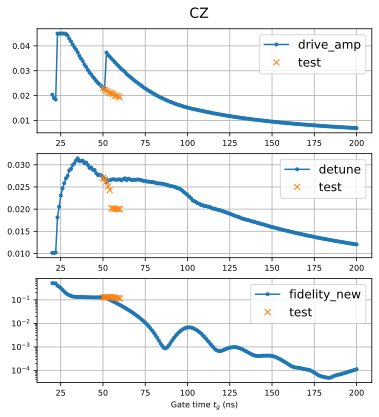

In [ ]:
fig, ax = plt.subplots(figsize=(6,6), nrows=3)
fig.suptitle('CZ', fontsize=14)
fig.subplots_adjust(top=0.93)
ax[0].plot(cz2['tg'], cz2['drive_amp'], '.-',  label=r'drive_amp')
ax[0].plot(df['tg'], df['drive_amp'], 'x',  label=r'test')
ax[1].plot(cz2['tg'], cz2['detune'], '.-',  label=r'detune')
ax[1].plot(df['tg'], df['detune'], 'x',  label=r'test')
ax[2].plot(cz2['tg'], 10**(cz2['f_200']), '.-',  label=r'fidelity_new')
# ax[2].plot(cz2['tg'], 10**(cz2['f_400']), '.-',  label=r'fidelity_new_400')
# plt.plot(cz_old['tg'], 10**(cz_old['fidelity_qt']), '.-',  label=r'fidelity_old')
ax[2].plot(df['tg'], 10**(df['f_200']), 'x',  label=r'test')
plt.xlabel('Gate time $t_g$ (ns)')
# ax[0].set_ylim(0.0065, 0.011)
# ax[1].set_ylim(0.011, 0.025)
ax[2].set_yscale('log')
for i in range(3):
    ax[i].legend(loc='best', fontsize=12)
    ax[i].grid()
    # ax[i].set_xlim(30, 70)
    # ax[i].set_xlim(150, 201)